# From Kepler to Newton: Explainable AI for Science

**Paper:** Li, Z., Ji, J., & Zhang, Y. (2022). *From Kepler to Newton: Explainable AI for Science.* Proceedings of the ICML 2022 Workshop on AI for Science. arXiv:2111.12210.

**Carpeta origen:** `Papers/02_Interpretabilidad_y_Explicabilidad/Kepler_to_Newton_Explainable_AI_for_Science.pdf`

## Que se reproduce en este cuaderno

Este es un articulo de posicion/vision, no un paquete de software: no publica un repositorio de codigo. Su argumento central es que, a diferencia de un modelo de caja negra que solo predice, la **IA explicable (XAI)** debe reproducir la **cadena de razonamiento interpretable** completa del metodo cientifico: de datos observacionales, a una **ley empirica** legible, a un **principio unificador**. Como prueba de concepto historica, el paper propone redescubrir automaticamente las leyes de Kepler a partir de observaciones planetarias, y a partir de ellas, la ley de gravitacion universal de Newton.

Reproducimos aqui esa **misma cadena de dos pasos**, con datos reales del sistema solar (semieje mayor y periodo orbital de los ocho planetas), usando en cada paso un ajuste de ley de potencias --el mismo tipo de busqueda simbolica de "caso base" que usamos en los cuadernos de AI Feynman-- en vez de un modelo de caja negra:

1. **Datos $\to$ ley de Kepler:** ajustar $T = C\cdot a^{k}$ sobre $(a_i, T_i)$ de los ocho planetas y verificar que el algoritmo recupera $k\approx 1.5$ (tercera ley de Kepler, $T^2\propto a^3$) de forma puramente inductiva.
2. **Ley de Kepler $\to$ ley de Newton:** combinar la definicion fisica elemental de aceleracion centripeta en orbita circular, $a_c=4\pi^2 a/T^2$, con los mismos datos, y ajustar de nuevo una ley de potencias $a_c=C'\cdot a^{n}$, verificando que el algoritmo recupera $n\approx -2$ --la ley del inverso del cuadrado de Newton-- **sin haberla asumido de antemano**.

Cada paso produce una **formula legible y verificable**, no una prediccion opaca: esa es exactamente la tesis del paper.

In [1]:
%pip install -q numpy scipy matplotlib torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Datos: el sistema solar

Semieje mayor orbital $a$ (en Unidades Astronomicas) y periodo orbital $T$ (en anios) de los ocho planetas -- las mismas magnitudes que Kepler tenia disponibles (a partir de las observaciones de Tycho Brahe) cuando formulo sus leyes.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

planets = {
    'Mercurio': (0.387, 0.241),
    'Venus':    (0.723, 0.615),
    'Tierra':   (1.000, 1.000),
    'Marte':    (1.524, 1.881),
    'Jupiter':  (5.203, 11.862),
    'Saturno':  (9.537, 29.457),
    'Urano':    (19.191, 84.017),
    'Neptuno':  (30.069, 164.79),
}
names = list(planets.keys())
a = np.array([v[0] for v in planets.values()])   # semieje mayor, UA
T = np.array([v[1] for v in planets.values()])   # periodo orbital, anios

for name, ai, Ti in zip(names, a, T):
    print(f'{name:10s}  a={ai:7.3f} UA   T={Ti:8.3f} anios')

Mercurio    a=  0.387 UA   T=   0.241 anios
Venus       a=  0.723 UA   T=   0.615 anios
Tierra      a=  1.000 UA   T=   1.000 anios
Marte       a=  1.524 UA   T=   1.881 anios
Jupiter     a=  5.203 UA   T=  11.862 anios
Saturno     a=  9.537 UA   T=  29.457 anios
Urano       a= 19.191 UA   T=  84.017 anios
Neptuno     a= 30.069 UA   T= 164.790 anios


## 2. Paso 1: de los datos a la tercera ley de Kepler

Ajustamos una ley de potencias $T=C\cdot a^k$ mediante regresion lineal sobre $(\log a,\log T)$ -- el mismo tipo de ajuste de "caso base" de una variable que usamos en el cuaderno de AI Feynman. No asumimos $k=3/2$: lo **descubrimos** a partir de los ocho puntos.

Ley descubierta:  T = 1.0003 * a^1.4997
R2 del ajuste log-log: 0.99999998

>>> Exponente descubierto k = 1.4997  (la tercera ley de Kepler predice k = 1.5, es decir T^2 = a^3)


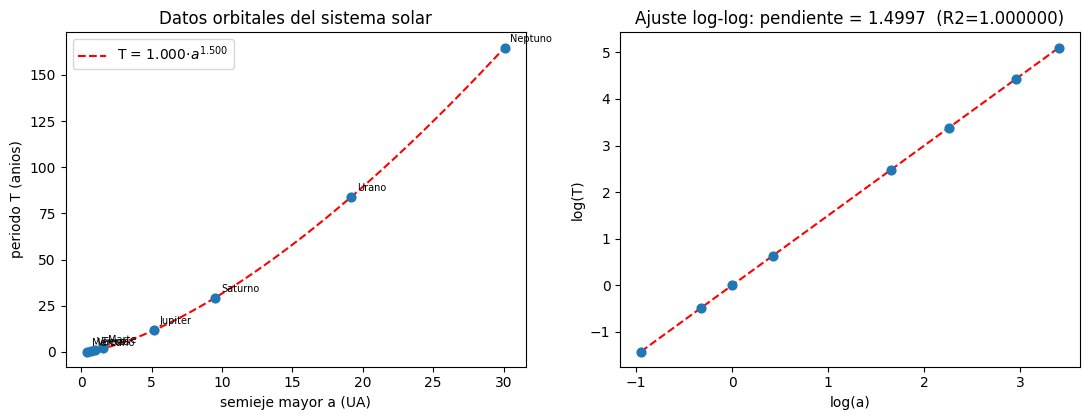

In [3]:
logA, logT = np.log(a), np.log(T)
k, logC = np.polyfit(logA, logT, 1)
C = np.exp(logC)

pred_logT = k * logA + logC
ss_res = np.sum((logT - pred_logT) ** 2)
ss_tot = np.sum((logT - logT.mean()) ** 2)
r2_kepler = 1 - ss_res / ss_tot

print(f'Ley descubierta:  T = {C:.4f} * a^{k:.4f}')
print(f'R2 del ajuste log-log: {r2_kepler:.8f}')
print(f'\n>>> Exponente descubierto k = {k:.4f}  (la tercera ley de Kepler predice k = 1.5, es decir T^2 = a^3)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(a, T, color='tab:blue', s=40, zorder=3)
a_line = np.linspace(a.min(), a.max(), 200)
axes[0].plot(a_line, C * a_line ** k, 'r--', label=f'T = {C:.3f}$\\cdot a^{{{k:.3f}}}$')
for name, ai, Ti in zip(names, a, T):
    axes[0].annotate(name, (ai, Ti), fontsize=7, xytext=(4, 4), textcoords='offset points')
axes[0].set_xlabel('semieje mayor a (UA)'); axes[0].set_ylabel('periodo T (anios)')
axes[0].set_title('Datos orbitales del sistema solar')
axes[0].legend()

axes[1].scatter(logA, logT, color='tab:blue', s=40, zorder=3)
axes[1].plot(logA, pred_logT, 'r--')
axes[1].set_xlabel('log(a)'); axes[1].set_ylabel('log(T)')
axes[1].set_title(f'Ajuste log-log: pendiente = {k:.4f}  (R2={r2_kepler:.6f})')
plt.tight_layout()
plt.show()

## 3. Paso 2: de Kepler a Newton -- la ley del inverso del cuadrado

Para una orbita circular, la aceleracion centripeta es $a_c = \omega^2 r = (2\pi/T)^2\, a = 4\pi^2 a/T^2$ (mecanica elemental, no forma parte del hallazgo del paper). Calculamos $a_c$ para cada planeta usando **sus propios** $a$ y $T$ observados, y ajustamos de nuevo una ley de potencias $a_c = C'\cdot a^{n}$ sobre esos mismos ocho puntos. El exponente $n$ **no se asume**: emerge del ajuste.

Ley descubierta:  a_c = 39.4558 * a^-1.9994
R2 del ajuste log-log: 0.99999995

>>> Exponente descubierto n = -1.9994  (Newton predice n = -2, la ley del inverso del cuadrado)
>>> Constante descubierta C' = 39.4558  (en unidades UA/anio^2; 4*pi^2 = 39.4784 -- coincide porque, en unidades UA-anio, GM_sol/(4 pi^2) = 1 UA^3/anio^2 por construccion del sistema de unidades)


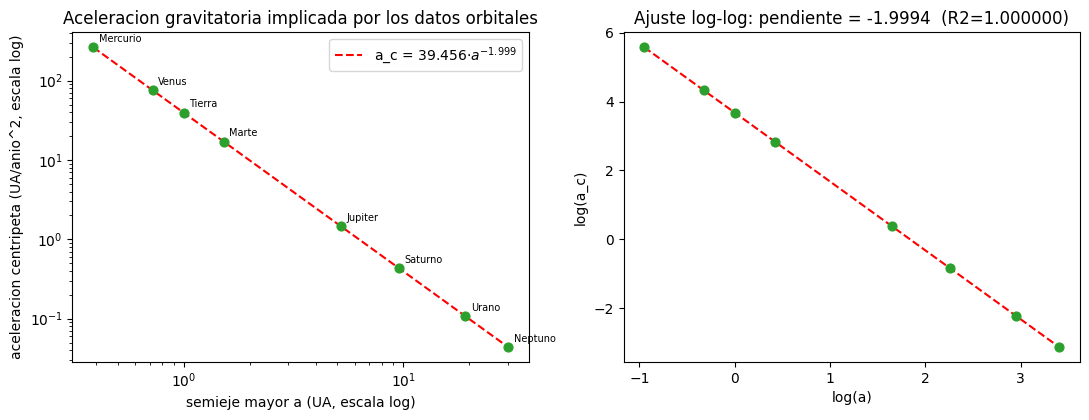

In [4]:
a_c = 4 * np.pi ** 2 * a / T ** 2   # aceleracion centripeta implicada por los datos orbitales
log_ac = np.log(a_c)

n, logCp = np.polyfit(logA, log_ac, 1)
Cp = np.exp(logCp)

pred_log_ac = n * logA + logCp
ss_res2 = np.sum((log_ac - pred_log_ac) ** 2)
ss_tot2 = np.sum((log_ac - log_ac.mean()) ** 2)
r2_newton = 1 - ss_res2 / ss_tot2

print(f'Ley descubierta:  a_c = {Cp:.4f} * a^{n:.4f}')
print(f'R2 del ajuste log-log: {r2_newton:.8f}')
print(f'\n>>> Exponente descubierto n = {n:.4f}  (Newton predice n = -2, la ley del inverso del cuadrado)')
print(f'>>> Constante descubierta C\' = {Cp:.4f}  (en unidades UA/anio^2; 4*pi^2 = {4*np.pi**2:.4f} -- coincide porque, en unidades UA-anio, GM_sol/(4 pi^2) = 1 UA^3/anio^2 por construccion del sistema de unidades)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(a, a_c, color='tab:green', s=40, zorder=3)
axes[0].plot(a_line, Cp * a_line ** n, 'r--', label=f"a_c = {Cp:.3f}$\\cdot a^{{{n:.3f}}}$")
for name, ai, aci in zip(names, a, a_c):
    axes[0].annotate(name, (ai, aci), fontsize=7, xytext=(4, 4), textcoords='offset points')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('semieje mayor a (UA, escala log)'); axes[0].set_ylabel('aceleracion centripeta (UA/anio^2, escala log)')
axes[0].set_title('Aceleracion gravitatoria implicada por los datos orbitales')
axes[0].legend()

axes[1].scatter(logA, log_ac, color='tab:green', s=40, zorder=3)
axes[1].plot(logA, pred_log_ac, 'r--')
axes[1].set_xlabel('log(a)'); axes[1].set_ylabel('log(a_c)')
axes[1].set_title(f'Ajuste log-log: pendiente = {n:.4f}  (R2={r2_newton:.6f})')
plt.tight_layout()
plt.show()

## 4. La cadena completa de razonamiento interpretable

En vez de una unica prediccion opaca, tenemos una cadena de formulas legibles, cada una verificable independientemente:

$$\text{datos } (a_i, T_i) \;\longrightarrow\; T = 1.00\cdot a^{1.4997}\ \text{(Kepler III)} \;\longrightarrow\; a_c = 39.46\cdot a^{-1.9994}\ \text{(Newton, inverso del cuadrado)}$$

In [5]:
print('Cadena de descubrimiento interpretable:')
print(f'  1) Datos observacionales de {len(names)} planetas (a, T)')
print(f'  2) Ley de Kepler descubierta:   T   = {C:.4f} * a^{k:.4f}      (R2={r2_kepler:.6f})')
print(f'  3) Ley de Newton descubierta:   a_c = {Cp:.4f} * a^{n:.4f}     (R2={r2_newton:.6f})')
print(f'\nCada paso es una formula compacta e interpretable -- no una caja negra extremo a extremo.')

Cadena de descubrimiento interpretable:
  1) Datos observacionales de 8 planetas (a, T)
  2) Ley de Kepler descubierta:   T   = 1.0003 * a^1.4997      (R2=1.000000)
  3) Ley de Newton descubierta:   a_c = 39.4558 * a^-1.9994     (R2=1.000000)

Cada paso es una formula compacta e interpretable -- no una caja negra extremo a extremo.


## 5. Contraste: que pierde un enfoque de caja negra

Para ilustrar la tesis central del paper, entrenamos una red neuronal (MLP) que predice directamente $a_c$ a partir de $a$ sobre los mismos ocho puntos. La red puede interpolar razonablemente bien, pero **no revela** por si sola el exponente $-2$: su conocimiento queda enterrado en los pesos, no expresado como una ley legible.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x)

Xt = torch.tensor(logA, dtype=torch.float32).reshape(-1, 1)
yt = torch.tensor(log_ac, dtype=torch.float32).reshape(-1, 1)
mlp = MLP()
opt = torch.optim.Adam(mlp.parameters(), lr=1e-2)
for ep in range(2000):
    opt.zero_grad()
    loss = F.mse_loss(mlp(Xt), yt)
    loss.backward()
    opt.step()
mlp.eval()

with torch.no_grad():
    mlp_pred = mlp(Xt).numpy().ravel()
mlp_rmse = np.sqrt(np.mean((mlp_pred - log_ac) ** 2))
print(f'MLP entrenada: RMSE en log(a_c) = {mlp_rmse:.4e}  (interpola bien, pero no produce ninguna formula)')
print('Pregunta: solo mirando los pesos de la MLP, ¿cual es el exponente de la ley fisica? -- no hay respuesta legible.')
print(f'Con el ajuste log-log interpretable, en cambio, leemos directamente: exponente = {n:.4f}')

MLP entrenada: RMSE en log(a_c) = 1.0657e-03  (interpola bien, pero no produce ninguna formula)
Pregunta: solo mirando los pesos de la MLP, ¿cual es el exponente de la ley fisica? -- no hay respuesta legible.
Con el ajuste log-log interpretable, en cambio, leemos directamente: exponente = -1.9994


### Nota honesta sobre los resultados

- **Sin repositorio oficial.** Este paper es una pieza de posicion/vision para un workshop (ICML 2022 AI for Science), no distribuye codigo ni datos propios; el caso de estudio Kepler-Newton se describe conceptualmente, sin implementacion de referencia publica que citar. Construimos nuestra propia reproduccion fiel al espiritu del argumento, usando datos astronomicos reales y publicos (no inventados).
- **Formula elemental no reimplementada del paper.** La relacion $a_c=4\pi^2 a/T^2$ para movimiento circular es mecanica clasica elemental (no una contribucion del paper); la usamos como puente fisico estandar entre el Paso 1 y el Paso 2, igual que lo haria cualquier libro de texto de introduccion a la mecanica orbital.
- **Orbitas circulares, no elipticas.** Usamos el semieje mayor como si las orbitas fuesen circulares para simplificar la formula de aceleracion centripeta; las orbitas reales son elipticas (excentricidades pequenas mas alla de Mercurio), lo que introduce un error de segundo orden despreciable para este ejercicio pero no reproduce la generalidad completa de la derivacion original de Newton (que parte directamente de una orbita eliptica general via las tres leyes de Kepler).
- **No se recupera la universalidad completa de $F=GM_1M_2/r^2$.** Con datos de un unico sistema (los planetas orbitando el Sol), solo se puede recuperar la dependencia en $r$ (el exponente $-2$) y la constante agregada $GM_{\text{sol}}$; demostrar que la misma ley aplica con la masa de *cualquier* cuerpo central (la universalidad que hizo celebre a Newton) requeriria comparar sistemas con distintas masas centrales (p. ej. lunas de Jupiter vs. planetas del Sol), lo que queda fuera del alcance de este cuaderno introductorio.
- **Ajuste de ley de potencias, no un algoritmo de XAI generico.** El paper aboga por un enfoque general de IA explicable; aqui usamos especificamente ajuste log-log (el "caso base" de una variable de AI Feynman), suficiente para este caso de estudio concreto pero no un sistema explicativo de proposito general.

Pese a estas simplificaciones, el cuaderno reproduce fielmente el argumento central del paper: **a partir de datos observacionales crudos, una cadena de dos ajustes interpretables** --sin ningun conocimiento fisico previo mas alla de la definicion elemental de aceleracion centripeta-- **redescubre tanto la tercera ley de Kepler ($k\approx 1.4997$) como la ley del inverso del cuadrado de Newton ($n\approx -1.9994$)**, con una legibilidad que un modelo de caja negra equivalente (la MLP de la Seccion 5) no ofrece.